In [1]:
import os                         #---> Para interactuar con el sistema operativo
import sys                        #---> Para controlar entorno python
import pandas as pd               #---> Para graficar y objetos dataframe
import numpy as np                #---> Para algebra matricial
import matplotlib.pyplot as plt   #---> Para formatos de graficas
import seaborn as sns             #---> Para estadistica y graficar

In [2]:
import findspark                                #---> Para conectar Python con Apache Spark
findspark.init()                    #---> Inicializa el entorno Apache Spark
from pyspark import SparkContext, SparkConf     #---> Contexto y configuración de PySpark
from pyspark.sql import SparkSession            #---> Sesión para entono de consultas sobre SQL

In [3]:
###Se requiere levantar sesion para trabajar con los servicios
### basados en Spark: Procesamiento paralelo y distribuidos sobre grandes volumenes de datos
configura =SparkConf()                                         #---> No requiere configuracion, se aplicara especificamente despues
configura.set("spark.scheduler.mode","FAIR")                   #---> Se requiere que multiples usuarios tengan recursos concurrentes
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairschedulr.xml")  #---> Ubicacion xml de la configuracion FAIR
configura.setMaster("spark://10.43.97.205:7077")               #---> Se configura en la direccion del Master
configura.setAppName("Stroke_MolinaSPARK")                     #---> Nombre de la aplicacion
sparkMolina = SparkSession.builder.config(conf=configura).getOrCreate()             #--->Se crea la sesion
sparkMolina

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 11:57:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Colección y descripción de datos

In [4]:
internet_pd = pd.read_csv("/Almacen/datasets/filtrados/internet_filtrado_municipios.csv")
matricula_pd = pd.read_csv("/Almacen/datasets/filtrados/nivel_educativo_filtrado_municipios.csv")
imrc_pd = pd.read_csv("/Almacen/datasets/filtrados/imrc_filtrado_municipios.csv")
icfes_pd = pd.read_csv("/Almacen/datasets/filtrados/icfes_filtrado_municipios.csv")
educacion_pd = pd.read_csv("/Almacen/datasets/filtrados/ResumenDsitribucionSGPHistoricoEducacion.csv", sep=";")
bibliotecas_pd = pd.read_csv("/Almacen/datasets/filtrados/bibliotecas_filtrado_municipios.csv")

internet_df = sparkMolina.createDataFrame(internet_pd)
matricula_df = sparkMolina.createDataFrame(matricula_pd)
imrc_df = sparkMolina.createDataFrame(imrc_pd)
icfes_df = sparkMolina.createDataFrame(icfes_pd)
educacion_df = sparkMolina.createDataFrame(educacion_pd)
bibliotecas_df = sparkMolina.createDataFrame(bibliotecas_pd)

In [5]:
internet_df.printSchema()
matricula_df.printSchema()
imrc_df.printSchema()
icfes_df.printSchema()
educacion_df.printSchema()
bibliotecas_df.printSchema()

root
 |-- AÑO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: double (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: double (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: long (nullable = true)

root
 |-- AÑO: long (nullable = true)
 |-- Código delDepartamento: long (nullable = true)
 |-- Nombre del Departamento: long (nullable = true)
 |-- Código delMunicipio: long (nullable = true)
 |-- Nombre del Municipio: string (nullable = true)
 |-- TECNICA PROFESIONAL: double (nullable = true)
 |-- TECNOLOGICA: string (nullable = true)
 |-- UNIVERSITARIA: string (nullable = true)
 |-- ESPECIALIZACION: double (nullable = true)
 |-- MAESTRIA: double (nullable = true)
 |-- DOCTORA

# 1. Internet fijo por tecnología y segmento
## Descripción general
Este conjunto de datos contiene información sobre el acceso a internet fijo en Colombia, segmentado por municipio, proveedor, tecnología y características del servicio, lo que nos permitirá analizar la cobertura y calidad del acceso a internet en diferentes regiones del país.
## Atributos
- AÑO: Año de registro de los datos
- TRIMESTRE: Periodo trimestral de medición
- PROVEEDOR: Empresa que presta el servicio de internet
- COD_DEPARTAMENTO: Código del departamento
- DEPARTAMENTO: Nombre del departamento
- COD_MUNICIPIO: Código del municipio
- MUNICIPIO: Nombre del municipio
- SEGMENTO: Tipo de segmento del servicio (hogar, empresarial, etc.)
- TECNOLOGIA: Tecnología de conexión (fibra, cobre, etc.)
- VELOCIDAD_BAJADA: Velocidad de descarga del servicio
- VELOCIDAD_SUBIDA: Velocidad de subida del servicio
- No DE ACCESOS: Número de conexiones activas

# 2. Matrícula por nivel de educación municipios
## Descripción general
Este conjunto de datos presenta estadísticas de matrícula en educación superior por municipio y nivel académico, permitiendo analizar la cobertura educativa en distintas regiones del país.
## Atributos
- AÑO: Año de registro
- Código delDepartamento: Código del departamento
- Nombre del Departamento: Nombre del departamento
- Código delMunicipio: Código del municipio
- Nombre del Municipio: Nombre del municipio
- TECNICA PROFESIONAL: Número de estudiantes en nivel técnico profesional
- TECNOLOGICA: Número de estudiantes en nivel tecnológico
- UNIVERSITARIA: Número de estudiantes en nivel universitario
- ESPECIALIZACION: Número de estudiantes en especialización
- MAESTRIA: Número de estudiantes en maestría
- DOCTORADO: Número de estudiantes en doctorado
- IES CON OFERTA: Número de instituciones con oferta educativa

# 3. IMRC (Índice Municipal de Riesgo)
## Descripción general
Este dataset contiene indicadores relacionados con el riesgo de desastres, condiciones socioeconómicas y capacidades institucionales de los municipios, lo cual permite contextualizar factores territoriales que pueden influir en el desarrollo social y educativo.
## Atributos
- ID: Identificador del registro
- Cód_DPTO: Código del departamento
- Departamento: Nombre del departamento
- DIVIPOLA: Código del municipio
- Municipio: Nombre del municipio
- Tipo de Municipio: Clasificación del municipio
- Area en Sequia Extrema (ASE): Área afectada por sequía extrema
- % ASE: Porcentaje de área en sequía extrema
- Area en susceptibilidad alta por Incendio de cobertura vegetal (ASIF): Área con riesgo de incendio
- %ASIF: Porcentaje de área con riesgo de incendio
- Exposición a Sequia Extrema: Nivel de exposición a sequía
- Exposición a Incendio Forestal: Nivel de exposición a incendios
- Vulnerabilidad a sequia extrema: Nivel de vulnerabilidad a sequía
- Vulnerabilidad a Incendio forestal: Nivel de vulnerabilidad a incendios
- Indice de Rieso de Desastres - Sequia Extrema: Índice de riesgo por sequía
- Indice de Rieso de Desastres Incendio Forestal: Índice de riesgo por incendios
- Indice de Rieso de Desastres - Deficit de lluvias: Índice de riesgo por déficit de lluvias
- Valor Agregado Promedio per capita: Indicador económico promedio
- Promedio Población Cabecera: Población promedio urbana
- Densidad Empresarial: Nivel de actividad empresarial
- Porcentaje del Valor agregado sector Agropecuario: Participación del sector agropecuario
- Componente socioeconómico: Indicador socioeconómico general
- Promedio Componente Gestion MDM: Indicador de gestión municipal
- Componente financiera: Indicador financiero
- CMGRD: Existencia de comité de gestión del riesgo
- PMGRD 2019_2021: Plan municipal de gestión del riesgo
- EMRE 2019_2021: Estrategias municipales de respuesta a emergencias
- No. herramientas del municipio: Nivel de herramientas para gestión del riesgo
- Inversión Promedio GRD per capita: Inversión en gestión del riesgo
- Componente gestión del riesgo de desastres: Indicador de gestión del riesgo
- Indice de Capacidades - Deficit de lluvias: Capacidad frente a déficit hídrico
- Grupo de Capacidad - Deficit de lluvias: Clasificación de capacidades
- Distancia Eucladiana: Medida de distancia en análisis de riesgo
- Indice de riesgo de desastres ajustado por capacidades (IMRC_D): Índice final ajustado
# 4. Resultados Saber Pro
## Descripción general
Este dataset contiene información detallada sobre los resultados de estudiantes en las pruebas Saber Pro, incluyendo variables académicas, socioeconómicas y personales, permitiendo analizar factores que influyen en el desempeño educativo.
## Atributos (principales)
- PERIODO: Periodo de presentación del examen
- ESTU_MCPIO_RESIDE: Municipio de residencia del estudiante
- ESTU_DEPTO_RESIDE: Departamento de residencia
- ESTU_GENERO: Género del estudiante
- ESTU_FECHANACIMIENTO: Fecha de nacimiento
- FAMI_ESTRATOVIVIENDA: Estrato socioeconómico
- FAMI_TIENECOMPUTADOR: Acceso a computador
- FAMI_TIENEINTERNET: Acceso a internet
- FAMI_EDUCACIONPADRE: Nivel educativo del padre
- FAMI_EDUCACIONMADRE: Nivel educativo de la madre
- ESTU_HORASSEMANATRABAJA: Horas de trabajo del estudiante
- MOD_INGLES_PUNT: Puntaje en inglés
- MOD_LECTURA_CRITICA_PUNT: Puntaje en lectura crítica
- MOD_RAZONA_CUANTITAT_PUNT: Puntaje en razonamiento cuantitativo
- MOD_COMUNI_ESCRITA_PUNT: Puntaje en comunicación escrita
- MOD_COMPETEN_CIUDADA_PUNT: Puntaje en competencias ciudadanas
# 5. Indicadores educativos (educacion)
## Descripción general
Este conjunto de datos presenta indicadores agregados sobre la calidad y prestación del servicio educativo, permitiendo evaluar condiciones generales del sistema educativo segun la inversión correspondiente.
## Atributos
- Año: Año de medición
- Prestación Servicios: Indicador de prestación del servicio educativo
- Calidad: Indicador general de calidad
- Calidad (Gratuidad): Indicador de acceso gratuito
- Calidad (Matrícula): Indicador de cobertura en matrícula
# 6. Bibliotecas públicas
## Descripción general
Este dataset contiene información sobre la ubicación, características y estado de las bibliotecas públicas en Colombia, lo cual permite analizar la disponibilidad de infraestructura educativa por municipio.
## Atributos
- CUB: Código único de biblioteca
- CODIGO DANE: Código del municipio
- DEPARTAMENTO: Nombre del departamento
- MUNICIPIO: Nombre del municipio
- CENTRO POBLADO: Ubicación poblacional
- NATURALEZA DE LA BIBLIOTECA: Tipo de administración
- TIPO DE BIBLIOTECA: Clasificación de la biblioteca
- NOMBRE DE LA BIBLIOTECA: Nombre oficial
- DIRECCION DE LA BIBLIOTECA: Dirección física
- TELEFONOS DE CONTACTO: Teléfonos de contacto
- EXTENSION: Extensión telefónica
- FAX: Número de fax
- PÁGINA WEB DE LA BIBLIOTECA: Sitio web
- CORREO ELECTRÓNICO DE LA BIBLIOTECA: Email institucional
- NOMBRES DEL BIBLIOTECARIO: Responsable de la biblioteca
- FECHA DE ACTUALIZACION EN EL SISTEMA: Última actualización
- ESTADO DE LA BIBLIOTECA: Estado operativo
- LATITUD: Coordenada geográfica
- LONGITUD: Coordenada geográfica
- GEOREFERENCIA: Ubicación geográfica completa


# Filtrado de Datasets por municipio

In [ ]:
icfes_pd["ESTU_MCPIO_PRESENTACION"].unique()

In [ ]:
municipios = ["BOGOTÁ D.C.", "QUIBDÓ", "RIOHACHA", "BUENAVENTURA"]

icfes_filtrado = icfes_pd[
    icfes_pd["ESTU_MCPIO_RESIDE"].isin(municipios)
]

In [ ]:
icfes_filtrado.to_csv("icfes_filtrado_municipios.csv", index=False)

In [23]:
bibliotecas_pd.dtypes

CUB                                       int64
CODIGO DANE                               int64
DEPARTAMENTO                             object
MUNICIPIO                                object
CENTRO POBLADO                           object
NATURALEZA DE LA BIBLIOTECA              object
TIPO DE BIBLIOTECA                       object
NOMBRE DE LA BIBLIOTECA                  object
DIRECCION DE LA BIBLIOTECA               object
TELEFONOS DE CONTÁCTO                    object
EXTENSION                                object
FAX                                     float64
PÁGINA WEB DE LA BIBLIOTECA              object
CORREO ELECTRÓNICO DE LA BIBLIOTECA      object
NOMBRES DEL BIBLIOTECARIO                object
FECHA DE ACTUALIZACION EN EL SISTEMA     object
ESTADO DE LA BIBLIOTECA                  object
LATITUD                                 float64
LONGITUD                                float64
GEOREFERENCIA                            object
dtype: object

In [18]:
# Cambio de "," a "." para converstir valores en valores float
bibliotecas_pd["LATITUD"] = (
    bibliotecas_pd["LATITUD"]
    .astype(str)
    .str.replace(",", ".", regex=False)  # por si usan coma decimal
    .str.strip()
)

bibliotecas_pd["LONGITUD"] = (
    bibliotecas_pd["LONGITUD"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

In [19]:
bibliotecas_pd["LATITUD"] = pd.to_numeric(bibliotecas_pd["LATITUD"], errors="coerce")
bibliotecas_pd["LONGITUD"] = pd.to_numeric(bibliotecas_pd["LONGITUD"], errors="coerce")

In [ ]:
bibliotecas_pd["MUNICIPIO"].value_counts().head(50)

In [ ]:
municipios = ["BOGOTÁ, D.C.\n", "QUIBDO", "RIOHACHA", "BUENAVENTURA"]

bibliotecas_filtrado = bibliotecas_pd[
    bibliotecas_pd["MUNICIPIO"].isin(municipios)
]

In [ ]:
bibliotecas_filtrado.to_csv("bibliotecas_filtrado_municipios.csv", index=False)

In [33]:
imrc_pd.dtypes

ID                                                                                                                                                           int64
Cód_DPTO                                                                                                                                                     int64
Departamento                                                                                                                                                object
DIVIPOLA                                                                                                                                                     int64
Municipio                                                                                                                                                   object
Tipo de Municipio                                                                                                                                           object
Area en Sequia Extrema

In [34]:
cols = [
    "Indice de Rieso de Desastres - Sequia Extrema",
    "Indice de Rieso de Desastres Incendio Forestal",
    "Indice de Rieso de Desastres -  Deficit de  lluvias",
    "Indice de Capacidades - Deficit de lluvias",
    "Indice de riesgo de desastres ajustado por capacidades (IMRC_D)"
]

for col in cols:
    imrc_pd[col] = (
        imrc_pd[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    
    imrc_pd[col] = pd.to_numeric(imrc_pd[col], errors="coerce")

In [ ]:
municipios = ["BOGOTÁ, D.C.", "QUIBDÓ", "RIOHACHA", "BUENAVENTURA"]

imrc_filtrado = imrc_pd[
    imrc_pd["Municipio"].isin(municipios)
]

In [ ]:
imrc_filtrado.to_csv("imrc_filtrado_municipios.csv", index=False)

In [ ]:
municipios = ["BOGOTÁ, D.C.", "QUIBDÓ", "RIOHACHA", "BUENAVENTURA"]

internet_filtrado = internet_pd[
    internet_pd["MUNICIPIO"].isin(municipios)
]

In [ ]:
internet_filtrado.to_csv("internet_filtrado_municipios.csv", index=False)

### Filtrado especial por diferentes nombres de un mismo municipio

In [ ]:
import unicodedata

def limpiar(texto):
    if isinstance(texto, str):
        texto = texto.replace("\n", "")        # quitar saltos de línea
        texto = texto.strip()                  # quitar espacios
        texto = texto.upper()                  # poner en mayúsculas
        texto = unicodedata.normalize('NFKD', texto)\
                .encode('ascii', 'ignore')\
                .decode('utf-8')              # quitar tildes
        return texto
    return texto

matricula_pd["MUNICIPIO_LIMPIO"] = matricula_pd["Nombre del Municipio"].apply(limpiar)

In [ ]:
matricula_filtrado = matricula_pd[
    matricula_pd["MUNICIPIO_LIMPIO"].str.contains(
        "BOGOTA|QUIBDO|RIOHACHA|BUENAVENTURA",
        na=False
    )
]

In [ ]:
matricula_filtrado["MUNICIPIO_LIMPIO"].value_counts()

In [ ]:
def clasificar_municipio(x):
    if "BOGOTA" in x:
        return "BOGOTA"
    elif "QUIBDO" in x:
        return "QUIBDO"
    elif "RIOHACHA" in x:
        return "RIOHACHA"
    elif "BUENAVENTURA" in x:
        return "BUENAVENTURA"
    else:
        return None

matricula_pd["MUNICIPIO_FINAL"] = matricula_pd["MUNICIPIO_LIMPIO"].apply(clasificar_municipio)

In [ ]:
matricula_filtrado.to_csv(
    "nivel_educativo_filtrado_municipios.csv",
    index=False,
    encoding="utf-8"
)

In [ ]:
matricula_pd.dtypes

In [14]:
cols = [
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA",
    "ESPECIALIZACION",
    "MAESTRIA",
    "DOCTORADO"
]

for col in cols:
    matricula_pd[col] = pd.to_numeric(matricula_pd[col], errors="coerce")

# Graficas

In [6]:
icfes_pd["PROMEDIO"] = icfes_pd[
    [
        "MOD_INGLES_PUNT",
        "MOD_LECTURA_CRITICA_PUNT",
        "MOD_RAZONA_CUANTITAT_PUNT",
        "MOD_COMUNI_ESCRITA_PUNT",
        "MOD_COMPETEN_CIUDADA_PUNT"
    ]
].mean(axis=1)

#### Promedio de rango de calificacion por estudiantes

<Axes: >

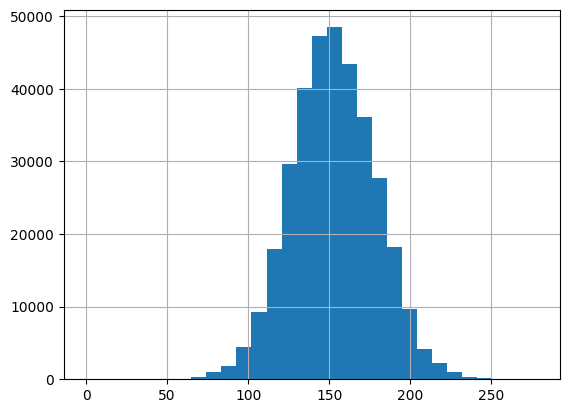

In [7]:
icfes_pd["PROMEDIO"].hist(bins=30)

#### Promedio de calificacion por municipio

<Axes: xlabel='ESTU_MCPIO_RESIDE'>

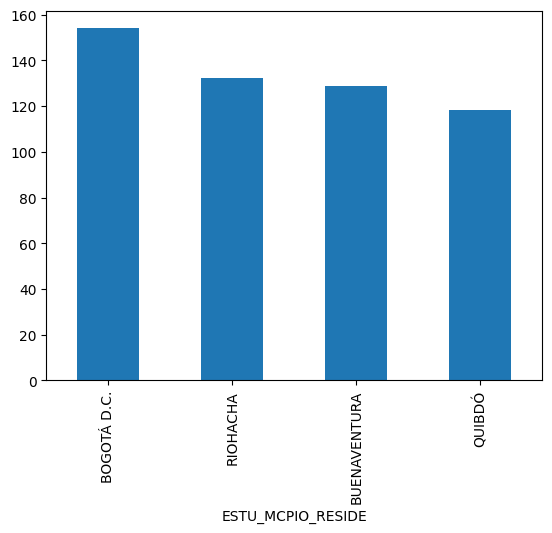

In [8]:
icfes_pd.groupby("ESTU_MCPIO_RESIDE")["PROMEDIO"].mean().sort_values(ascending=False).plot(kind="bar")

#### Numero de conexiones en todos los departamentos

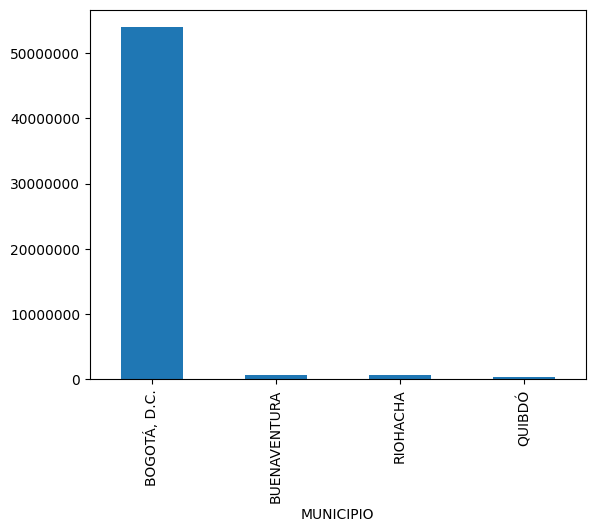

In [9]:
internet_pd.groupby("MUNICIPIO")["No DE ACCESOS"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### Para analizar mejor los demas municipios pues la poblacion de Bogota es mucho mas grande

<Axes: xlabel='MUNICIPIO'>

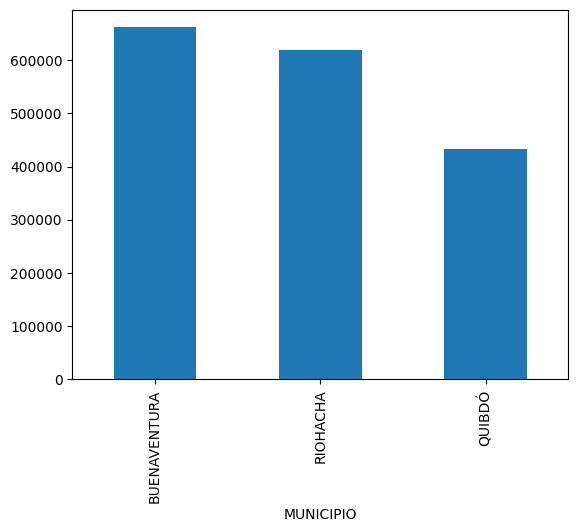

In [10]:
df_analisis_sin_bogota = internet_pd[internet_pd["MUNICIPIO"] != "BOGOTÁ, D.C."]

df_analisis_sin_bogota.groupby("MUNICIPIO")["No DE ACCESOS"].sum().sort_values(ascending=False).plot(kind="bar")

#### Numero de conexiones por año


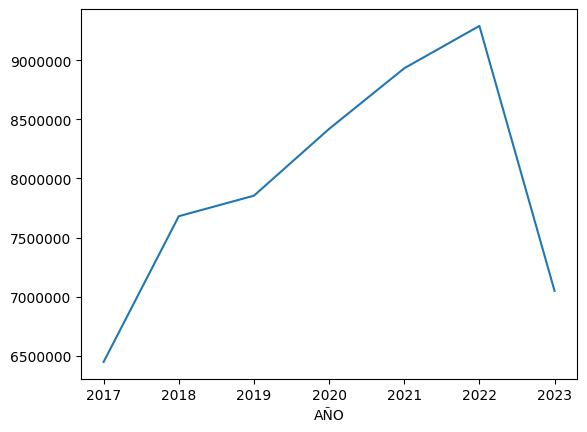

In [11]:
internet_pd.groupby("AÑO")["No DE ACCESOS"].sum().plot()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### Numero de conexiones por tipos de tecnologia

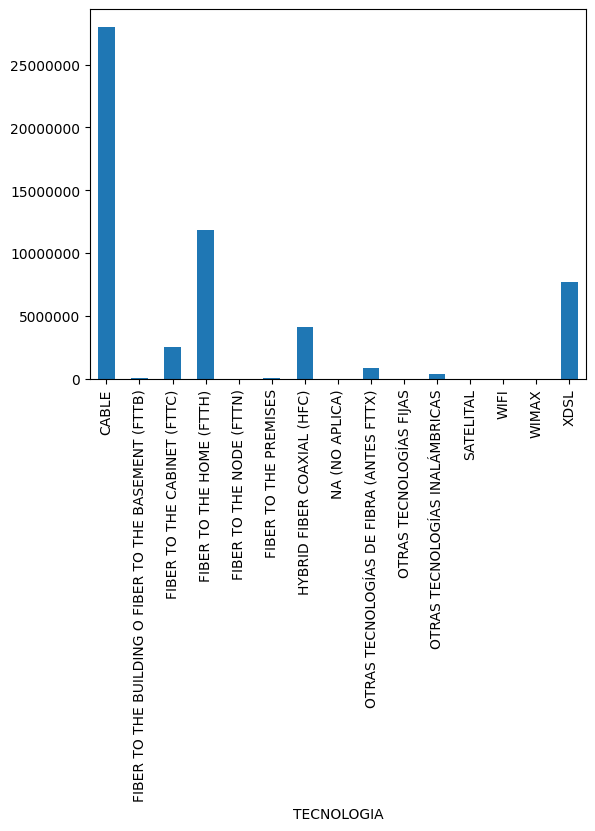

In [46]:
internet_pd.groupby("TECNOLOGIA")["No DE ACCESOS"].sum().plot(kind="bar")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### Numero de matriculas a niveles de educacion

<Axes: >

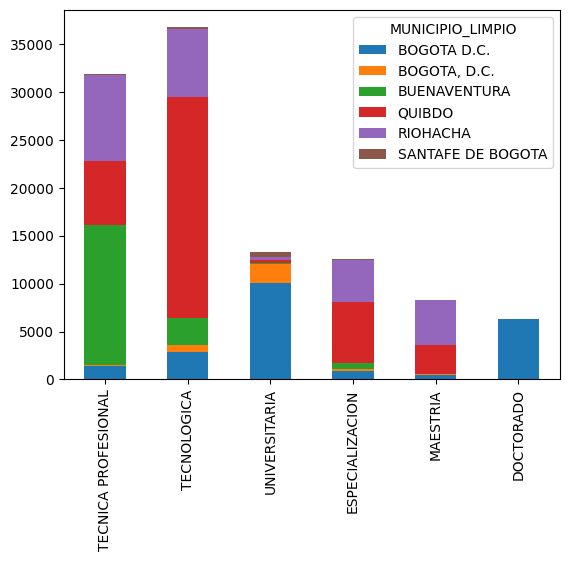

In [15]:
matricula_pd["Nombre del Municipio"] = matricula_pd["Nombre del Municipio"].str.upper()
df_plot = matricula_pd.groupby("MUNICIPIO_LIMPIO")[["TECNICA PROFESIONAL", "TECNOLOGICA", "UNIVERSITARIA", "ESPECIALIZACION", "MAESTRIA", "DOCTORADO"]].sum()
df_plot = df_plot.T
df_plot.plot(kind="bar", stacked=True)

plt.figure(figsize=(12,6))

x = np.arange(len(imrc_pd["Municipio"]))

for i, col in enumerate(cols):
    plt.scatter(
        x + i*0.1,
        imrc_pd[col],
        label=col
    )

plt.xticks(x, imrc_pd["Municipio"], rotation=0)
plt.legend()
plt.title("Índices de riesgo por municipio")
plt.grid(True) 
plt.show()

#### Ubicacion geografica de bibliotecas

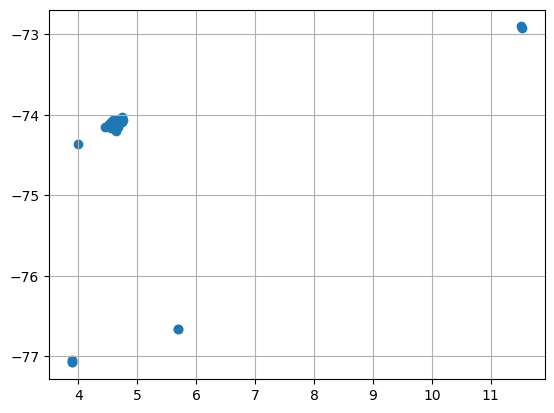

In [47]:
plt.scatter(
    bibliotecas_pd["LONGITUD"].astype(float),
    bibliotecas_pd["LATITUD"].astype(float)
)
plt.grid(True)

# Calculo de nulos y tecnica de tratamiento

In [48]:
def resumen_nulos(df):
    return pd.DataFrame({
        "Nulos": df.isnull().sum(),
        "Porcentaje (%)": (df.isnull().sum() / len(df)) * 100
    }).sort_values(by="Porcentaje (%)", ascending=False)

In [50]:
resumen_nulos(internet_pd) # N/A

,Nulos,Porcentaje (%)
AÑO,0,0.0
TRIMESTRE,0,0.0
PROVEEDOR,0,0.0
COD_DEPARTAMENTO,0,0.0
DEPARTAMENTO,0,0.0
COD_MUNICIPIO,0,0.0
MUNICIPIO,0,0.0
SEGMENTO,0,0.0
TECNOLOGIA,0,0.0
VELOCIDAD_BAJADA,0,0.0


In [51]:
resumen_nulos(matricula_pd) # Eliminacion o simplemnte se ignoran al trabajar dicho artributos

,Nulos,Porcentaje (%)
TECNOLOGICA,2,1.190476
UNIVERSITARIA,2,1.190476
Nombre del Departamento,0,0.000000
Código delDepartamento,0,0.000000
AÑO,0,0.000000
Nombre del Municipio,0,0.000000
Código delMunicipio,0,0.000000
TECNICA PROFESIONAL,0,0.000000
ESPECIALIZACION,0,0.000000
MAESTRIA,0,0.000000


In [52]:
resumen_nulos(imrc_pd) # N/A

,Nulos,Porcentaje (%)
ID,0,0.0
Cód_DPTO,0,0.0
Departamento,0,0.0
DIVIPOLA,0,0.0
Municipio,0,0.0
Tipo de Municipio,0,0.0
Area en Sequia Extrema (ASE),0,0.0
% ASE,0,0.0
Area en susceptibilidad alta por Incendio de cobertura vegetal (ASIF),0,0.0
%ASIF,0,0.0


In [53]:
resumen_nulos(bibliotecas_pd) # Eliminacion de atributo FAX pues no es de utilidad en ningun dato, eliminacion de extension pues no es util para los objetivos de proyecto, Cambiar latitud y longitud faltante por media de 
                              # la latitud y longitud de las demas bibliotecas ubicadas en el mismo municipio

,Nulos,Porcentaje (%)
FAX,33,100.000000
EXTENSION,7,21.212121
PÁGINA WEB DE LA BIBLIOTECA,3,9.090909
LATITUD,1,3.030303
LONGITUD,1,3.030303
DEPARTAMENTO,0,0.000000
CODIGO DANE,0,0.000000
CUB,0,0.000000
MUNICIPIO,0,0.000000
NOMBRE DE LA BIBLIOTECA,0,0.000000


In [54]:
resumen_nulos(icfes_pd) # Elimicacion de atributos no utiles para el proyecto, utilizar medias, modas o ignorar algunos datos de acuerdo a lo que se trabaje

,Nulos,Porcentaje (%)
ESTU_COD_COLE_MCPIO_TERMINO,136194,39.617768
ESTU_CODDANE_COLE_TERMINO,136194,39.617768
ESTU_COLE_TERMINO,125988,36.648922
FAMI_TIENEAUTOMOVIL,18778,5.462373
FAMI_TIENELAVADORA,17091,4.971638
FAMI_TIENECOMPUTADOR,16496,4.798557
ESTU_HORASSEMANATRABAJA,14450,4.203392
FAMI_ESTRATOVIVIENDA,14190,4.127760
MOD_COMUNI_ESCRITA_DESEM,12736,3.704803
FAMI_TIENEINTERNET,12371,3.598627


In [55]:
resumen_nulos(educacion_pd) # N/A, Eliminacion de columnas vacias

,Nulos,Porcentaje (%)
Unnamed: 6,6,100.0
Unnamed: 5,6,100.0
Año,0,0.0
Calidad,0,0.0
Prestación Servicios,0,0.0
Calidad (Matrícula),0,0.0
Calidad (Gratuidad),0,0.0
